In [2]:
"""
Необходимые файлы, лекционные файлы
"""

# 5.py
class Stack:
    def __init__(self):
        self.items = []

    def isEmpty(self):
        return self.items == []

    def push(self, item):
        self.items.append(item)

    def pop(self):
        return self.items.pop()

    def peek(self):
        return self.items[-1]

    def size(self):
        return len(self.items)


class BinaryTree:
    def __init__(self, rootObj):
        self.key = rootObj
        self.leftChild = None
        self.rightChild = None

    def insertLeft(self, newNode):
        if self.leftChild == None:
            self.leftChild = BinaryTree(newNode)
        else:
            t = BinaryTree(newNode)
            t.leftChild = self.leftChild
            self.leftChild = t

    def insertRight(self, newNode):
        if self.rightChild == None:
            self.rightChild = BinaryTree(newNode)
        else:
            t = BinaryTree(newNode)
            t.rightChild = self.rightChild
            self.rightChild = t

    def getRightChild(self):
        return self.rightChild

    def getLeftChild(self):
        return self.leftChild

    def setRootVal(self, obj):
        self.key = obj

    def getRootVal(self):
        return self.key


def buildParseTree(fpexp):
    fplist = fpexp.split()
    pStack = Stack()
    eTree = BinaryTree('')
    pStack.push(eTree)
    currentTree = eTree
    for i in fplist:
        if i == '(':
            currentTree.insertLeft('')
            pStack.push(currentTree)
            currentTree = currentTree.getLeftChild()
        elif i not in ['+', '-', '*', '/', ')']:
            currentTree.setRootVal(int(i))
            parent = pStack.pop()
            currentTree = parent
        elif i in ['+', '-', '*', '/']:
            currentTree.setRootVal(i)
            currentTree.insertRight('')
            pStack.push(currentTree)
            currentTree = currentTree.getRightChild()
        elif i == ')':
            currentTree = pStack.pop()
        else:
            raise ValueError
    return eTree


def evaluate(parseTree):
    opers = {'+': lambda x, y: x + y, '-': lambda x, y: x - y,
             '*': lambda x, y: x * y, '/': lambda x, y: x / y}

    leftC = parseTree.getLeftChild()
    rightC = parseTree.getRightChild()

    if leftC and rightC:
        fn = opers[parseTree.getRootVal()]
        return fn(evaluate(leftC),evaluate(rightC))
    else:
        return parseTree.getRootVal()

pt = buildParseTree("( ( 10 + 5 ) * 3 )")

print(evaluate(pt))

45


№ 1<br/>
**(3 балла)**<br/>
a) Перепишите функции buildParseTree и evaluate из лекционных материалов так,
чтобы они работали с логическими выражениями, то есть с операторами «и», «или»,
«не» и операндами «истина» и «ложь». Помните, что «не» – унарный оператор.

b) Реализуйте функцию printexp, которая будет принимать дерево синтаксического
разбора и возвращать строку соответствующего ему логического выражения.

In [ ]:

def buildParseTree(fpexp):
    # 
    fpexp = fpexp.replace('(', ' ( ').replace(')', ' ) ')
    fplist = fpexp.split()
    pStack = Stack()
    eTree = BinaryTree('')
    pStack.push(eTree)  
    currentTree = eTree
    for i in fplist:
        if i == '(':
            currentTree.insertLeft('')
            pStack.push(currentTree)
            currentTree = currentTree.getLeftChild()

        elif i == 'not':
            # Унарный оператор: устанавливаем значение текущего узла
            # и создаем левого потомка для операнда (т.к. not X)
            currentTree.setRootVal('not')
            currentTree.insertLeft('')
            pStack.push(currentTree)
            currentTree = currentTree.getLeftChild()

        elif i in ['and', 'or']:
            currentTree.setRootVal(i)
            currentTree.insertRight('')
            pStack.push(currentTree)
            currentTree = currentTree.getRightChild()

        elif i == ')':
            currentTree = pStack.pop()

        elif i in ['True', 'False']:
            # Операнд: преобразуем строку в булево значение
            # Если токен не является оператором или скобкой, считаем его операндом
            val = True if i == 'True' else False
            currentTree.setRootVal(val)
            parent = pStack.pop()
            currentTree = parent

        else:
            raise ValueError
        
    return eTree


def evaluate(parseTree):
    opers = {
        'and': lambda x, y: x and y, 
        'or': lambda x, y: x or y,
        'not': lambda x, y: not x
    }

    leftC = parseTree.getLeftChild()
    rightC = parseTree.getRightChild()

    if leftC and rightC:
        fn = opers[parseTree.getRootVal()]
        return fn(evaluate(leftC), evaluate(rightC))
    elif leftC and parseTree.getRootVal() == 'not':
        fn = opers['not']
        return fn(evaluate(leftC))
    else:
        return parseTree.getRootVal()

def printexp(tree):
    if not tree:
        return ""
        
    val = tree.getRootVal()
    
    if tree.getLeftChild() is None and tree.getRightChild() is None:
        return str(val)
    
    if val == 'not':
        return f"( not {printexp(tree.getLeftChild())} )"
    
    return f"( {printexp(tree.getLeftChild())} {val} {printexp(tree.getRightChild())} )"

expr1 = "( ( True and False ) or True )"
pt1 = buildParseTree(expr1)
print(f"Выражение: {printexp(pt1)}")
print(f"Результат: {evaluate(pt1)}")

print('-' * 50)

expr2 = "( not True )"
pt2 = buildParseTree(expr2)
print(f"Выражение: {printexp(pt2)}")
print(f"Результат: {evaluate(pt2)}")

Выражение: ( ( True and False ) or True )
Результат: True
--------------------------------------------------
Выражение: ( ( not True )   )
Результат: 


In [ ]:
class TreeNode:
    def __init__(self, key, val, left=None, right=None, parent=None):
        self.key = key
        self.payload = val
        self.leftChild = left
        self.rightChild = right
        self.parent = parent

    def hasLeftChild(self):
        return self.leftChild

    def hasRightChild(self):
        return self.rightChild

    def isLeftChild(self):
        return self.parent and self.parent.leftChild == self

    def isRightChild(self):
        return self.parent and self.parent.rightChild == self

    def isRoot(self):
        return not self.parent

    def isLeaf(self):
        return not (self.rightChild or self.leftChild)

    def hasAnyChildren(self):
        return self.rightChild or self.leftChild

    def hasBothChildren(self):
        return self.rightChild and self.leftChild

    def replaceNodeData(self, key, value, lc, rc):
        self.key = key
        self.payload = value
        self.leftChild = lc
        self.rightChild = rc
        if self.hasLeftChild():
            self.leftChild.parent = self
        if self.hasRightChild():
            self.rightChild.parent = self


class BinarySearchTree:

    def __init__(self):
        self.root = None
        self.size = 0

    def length(self):
        return self.size

    def __len__(self):
        return self.size

    def put(self, key, val):
        if self.root:
            self._put(key, val, self.root)
        else:
            self.root = TreeNode(key, val)
        self.size = self.size + 1

    def _put(self, key, val, currentNode):
        if key < currentNode.key:
            if currentNode.hasLeftChild():
                self._put(key, val, currentNode.leftChild)
            else:
                currentNode.leftChild = TreeNode(key, val, parent=currentNode)
        else:
            if currentNode.hasRightChild():
                self._put(key, val, currentNode.rightChild)
            else:
                currentNode.rightChild = TreeNode(key, val, parent=currentNode)

    def __setitem__(self, k, v):
        self.put(k, v)

    def get(self, key):
        if self.root:
            res = self._get(key, self.root)
            if res:
                return res.payload
            else:
                return None
        else:
            return None

    def _get(self, key, currentNode):
        if not currentNode:
            return None
        elif currentNode.key == key:
            return currentNode
        elif key < currentNode.key:
            return self._get(key, currentNode.leftChild)
        else:
            return self._get(key, currentNode.rightChild)

    def __getitem__(self, key):
        return self.get(key)

    def __contains__(self, key):
        if self._get(key, self.root):
            return True
        else:
            return False

    def delete(self, key):
        if self.size > 1:
            nodeToRemove = self._get(key, self.root)
            if nodeToRemove:
                self.remove(nodeToRemove)
                self.size = self.size - 1
            else:
                raise KeyError('Error, key not in tree')
        elif self.size == 1 and self.root.key == key:
            self.root = None
            self.size = self.size - 1
        else:
            raise KeyError('Error, key not in tree')

    def __delitem__(self, key):
        self.delete(key)

    def spliceOut(self):
        if self.isLeaf():
            if self.isLeftChild():
                self.parent.leftChild = None
            else:
                self.parent.rightChild = None
        elif self.hasAnyChildren():
            if self.hasLeftChild():
                if self.isLeftChild():
                    self.parent.leftChild = self.leftChild
                else:
                    self.parent.rightChild = self.leftChild
                self.leftChild.parent = self.parent
            else:
                if self.isLeftChild():
                    self.parent.leftChild = self.rightChild
                else:
                    self.parent.rightChild = self.rightChild
                self.rightChild.parent = self.parent

    def findSuccessor(self):
        succ = None
        if self.hasRightChild():
            succ = self.rightChild.findMin()
        else:
            if self.parent:
                if self.isLeftChild():
                    succ = self.parent
                else:
                    self.parent.rightChild = None
                    succ = self.parent.findSuccessor()
                    self.parent.rightChild = self
        return succ

    def findMin(self):
        current = self
        while current.hasLeftChild():
            current = current.leftChild
        return current

    def remove(self, currentNode):
        if currentNode.isLeaf():  # leaf
            if currentNode == currentNode.parent.leftChild:
                currentNode.parent.leftChild = None
            else:
                currentNode.parent.rightChild = None
        elif currentNode.hasBothChildren():  # interior
            succ = currentNode.findSuccessor()
            succ.spliceOut()
            currentNode.key = succ.key
            currentNode.payload = succ.payload

        else:  # this node has one child
            if currentNode.hasLeftChild():
                if currentNode.isLeftChild():
                    currentNode.leftChild.parent = currentNode.parent
                    currentNode.parent.leftChild = currentNode.leftChild
                elif currentNode.isRightChild():
                    currentNode.leftChild.parent = currentNode.parent
                    currentNode.parent.rightChild = currentNode.leftChild
                else:
                    currentNode.replaceNodeData(currentNode.leftChild.key,
                                                currentNode.leftChild.payload,
                                                currentNode.leftChild.leftChild,
                                                currentNode.leftChild.rightChild)
            else:
                if currentNode.isLeftChild():
                    currentNode.rightChild.parent = currentNode.parent
                    currentNode.parent.leftChild = currentNode.rightChild
                elif currentNode.isRightChild()
                    currentNode.rightChild.parent = currentNode.parent
                    currentNode.parent.rightChild = currentNode.rightChild
                else:
                    currentNode.replaceNodeData(currentNode.rightChild.key,
                                                currentNode.rightChild.payload,
                                                currentNode.rightChild.leftChild,
                                                currentNode.rightChild.rightChild)

№ 2<br/>
**(3 балла)**<br/>
a) Реализуйте функцию has_no_duplicates, которая принимает в качестве аргумента
двоичное дерево поиска и возвращает «истину» если в нем нет равных ключей и
«ложь» в противном случае.

b) Измените реализацию двоичного дерева поиска из лекционных материалов так,
чтобы оно правильно работало с дубликатами ключей. Т.е., если ключ в дереве уже
присутствует, то новое значение должно заменить старое, вместо того, чтобы
добавлять новый узел с тем же ключом. Проверьте правильность вашего решения
функцией has_no_duplicates.


In [ ]:
class TreeNode:
    def __init__(self, key, val, left=None, right=None, parent=None):
        self.key = key
        self.payload = val
        self.leftChild = left
        self.rightChild = right
        self.parent = parent

    def hasLeftChild(self):
        return self.leftChild

    def hasRightChild(self):
        return self.rightChild

    def isLeftChild(self):
        return self.parent and self.parent.leftChild == self

    def isRightChild(self):
        return self.parent and self.parent.rightChild == self

    def isRoot(self):
        return not self.parent

    def isLeaf(self):
        return not (self.rightChild or self.leftChild)

    def hasAnyChildren(self):
        return self.rightChild or self.leftChild

    def hasBothChildren(self):
        return self.rightChild and self.leftChild

    def replaceNodeData(self, key, value, lc, rc):
        self.key = key
        self.payload = value
        self.leftChild = lc
        self.rightChild = rc
        if self.hasLeftChild():
            self.leftChild.parent = self
        if self.hasRightChild():
            self.rightChild.parent = self


class BinarySearchTree:

    def __init__(self):
        self.root = None
        self.size = 0

    def length(self):
        return self.size

    def __len__(self):
        return self.size

    def put(self, key, val):
        if self.root:
            self._put(key, val, self.root)
        else:
            self.root = TreeNode(key, val)
            # Увеличиваем размер только при создании корня
            self.size = self.size + 1

    # Изменённый метод put
    def _put(self, key, val, currentNode):
        if key < currentNode.key:
            if currentNode.hasLeftChild():
                self._put(key, val, currentNode.leftChild)
            else:
                currentNode.leftChild = TreeNode(key, val, parent=currentNode)
                # Увеличиваем размер при добавлении нового узла
                self.size += 1
        # Явно проверяем, что ключ больше
        elif key > currentNode.key:
            if currentNode.hasRightChild():
                self._put(key, val, currentNode.rightChild)
            else:
                currentNode.rightChild = TreeNode(key, val, parent=currentNode)
                # Увеличиваем размер при добавлении нового узла
                self.size += 1
        # Заменяем значение, не создаем новый узел и не увеличиваем size
        else:
            currentNode.payload = val

    def __setitem__(self, k, v):
        self.put(k, v)

    def get(self, key):
        if self.root:
            res = self._get(key, self.root)
            if res:
                return res.payload
            else:
                return None
        else:
            return None

    def _get(self, key, currentNode):
        if not currentNode:
            return None
        elif currentNode.key == key:
            return currentNode
        elif key < currentNode.key:
            return self._get(key, currentNode.leftChild)
        else:
            return self._get(key, currentNode.rightChild)

    def __getitem__(self, key):
        return self.get(key)

    def __contains__(self, key):
        if self._get(key, self.root):
            return True
        else:
            return False

    def delete(self, key):
        if self.size > 1:
            nodeToRemove = self._get(key, self.root)
            if nodeToRemove:
                self.remove(nodeToRemove)
                self.size = self.size - 1
            else:
                raise KeyError('Error, key not in tree')
        elif self.size == 1 and self.root.key == key:
            self.root = None
            self.size = self.size - 1
        else:
            raise KeyError('Error, key not in tree')

    def __delitem__(self, key):
        self.delete(key)

    def spliceOut(self):
        if self.isLeaf():
            if self.isLeftChild():
                self.parent.leftChild = None
            else:
                self.parent.rightChild = None
        elif self.hasAnyChildren():
            if self.hasLeftChild():
                if self.isLeftChild():
                    self.parent.leftChild = self.leftChild
                else:
                    self.parent.rightChild = self.leftChild
                self.leftChild.parent = self.parent
            else:
                if self.isLeftChild():
                    self.parent.leftChild = self.rightChild
                else:
                    self.parent.rightChild = self.rightChild
                self.rightChild.parent = self.parent

    def findSuccessor(self):
        succ = None
        if self.hasRightChild():
            succ = self.rightChild.findMin()
        else:
            if self.parent:
                if self.isLeftChild():
                    succ = self.parent
                else:
                    self.parent.rightChild = None
                    succ = self.parent.findSuccessor()
                    self.parent.rightChild = self
        return succ

    def findMin(self):
        current = self
        while current.hasLeftChild():
            current = current.leftChild
        return current

    def remove(self, currentNode):
        if currentNode.isLeaf():
            if currentNode == currentNode.parent.leftChild:
                currentNode.parent.leftChild = None
            else:
                currentNode.parent.rightChild = None
        elif currentNode.hasBothChildren():
            succ = currentNode.findSuccessor()
            succ.spliceOut()
            currentNode.key = succ.key
            currentNode.payload = succ.payload

        else:
            if currentNode.hasLeftChild():
                if currentNode.isLeftChild():
                    currentNode.leftChild.parent = currentNode.parent
                    currentNode.parent.leftChild = currentNode.leftChild
                elif currentNode.isRightChild():
                    currentNode.leftChild.parent = currentNode.parent
                    currentNode.parent.rightChild = currentNode.leftChild
                else:
                    currentNode.replaceNodeData(currentNode.leftChild.key,
                                                currentNode.leftChild.payload,
                                                currentNode.leftChild.leftChild,
                                                currentNode.leftChild.rightChild)
            else:
                if currentNode.isLeftChild():
                    currentNode.rightChild.parent = currentNode.parent
                    currentNode.parent.leftChild = currentNode.rightChild
                elif currentNode.isRightChild():
                    currentNode.rightChild.parent = currentNode.parent
                    currentNode.parent.rightChild = currentNode.rightChild
                else:
                    currentNode.replaceNodeData(currentNode.rightChild.key,
                                                currentNode.rightChild.payload,
                                                currentNode.rightChild.leftChild,
                                                currentNode.rightChild.rightChild)
                    
def has_no_duplicates(tree):
    if tree.root is None:
        return True

    keys = []
    
    def _inorder(node):
        if node:
            _inorder(node.leftChild)
            keys.append(node.key)
            _inorder(node.rightChild)

    _inorder(tree.root)
    
    return len(keys) == len(set(keys))

mytree = BinarySearchTree()
mytree[3] = "red"
mytree[5] = "blue"
mytree[2] = "yellow"

print(f"Значение ключа 5: {mytree[5]}")
print(f"Размер дерева: {len(mytree)}")
print(f"Дубликатов нет: {has_no_duplicates(mytree)}")
print("-" * 20)

print("Добавляем mytree[5] = 'white'")
mytree[5] = "white"

print(f"Значение ключа 5: {mytree[5]}")
print(f"Размер дерева: {len(mytree)}")
print(f"Дубликатов нет: {has_no_duplicates(mytree)}")

Значение ключа 5: blue
Размер дерева: 3
Дубликатов нет: True
--------------------
Добавляем mytree[5] = 'white'
Значение ключа 5: blue
Размер дерева: 4
Дубликатов нет: False


№ 3<br/>
**(5 баллов)**<br/>
Суть игры «Животные» заключается в следующем: программа пытается угадать
задуманное пользователем животное и при этом самообучается, то есть постепенно
совершенствуется. Вся необходимая информация хранится в бинарном дереве, каждая
вершина которого содержит вопрос, предполагающий ответ «да» или «нет».
Последовательный выбор одного из этих ответов ведет программу вниз по
соответствующим ветвям до терминальной вершины, где и находится название животного.
Если программа совершает ошибку, она просит пользователя ввести уточняющий вопрос,
который позволил бы ей прийти к верному решению, затем добавляет его в новую
внутреннюю вершину и создает для нее свои листья.
Предположим, текущая база знаний программы выглядит так, как на рисунке, и
пользователь загадал змею. В таблице приводятся список вопросов, которые задает
программа, и полученные ответы пользователя.<br/>
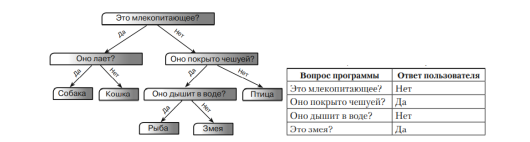<br/>
Если задуман жираф, вопросы и ответы прозвучат иначе, а программа добавит в дерево
уточняющую информацию и нужное животное.<br/>
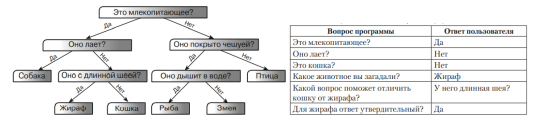<br/>
Реализуйте эту игру, используя бинарное дерево для хранения вопросов и ответов

In [4]:
def BinaryTree(r):
    return [r, [], []]


def insertLeft(root, newBranch):
    t = root.pop(1)
    if len(t) > 1:
        root.insert(1, [newBranch, t, []])
    else:
        root.insert(1, [newBranch, [], []])
    return root


def insertRight(root, newBranch):
    t = root.pop(2)
    if len(t) > 1:
        root.insert(2, [newBranch, [], t])
    else:
        root.insert(2, [newBranch, [], []])
    return root


def getRootVal(root):
    return root[0]


def setRootVal(root, newVal):
    root[0] = newVal


def getLeftChild(root):
    return root[1]


def getRightChild(root):
    return root[2]


In [ ]:
# [текст, no(лево), yes(право)]

def leaf(text):
    return [text, [], []]

def is_leaf(node):
    return node[1] == [] and node[2] == []

def ask(prompt):
    while True:
        a = input(prompt + " (да/нет): ").strip().lower()
        if a in ("да", "д", "y", "yes"):
            return True
        if a in ("нет", "н", "n", "no"):
            return False
        print("Введите да или нет.")

def play(tree):
    node = tree

    while not is_leaf(node):
        if ask(node[0]):
            node = node[2]   # да -> вправо
        else:
            node = node[1]   # нет -> влево

    guess = node[0]
    if ask(f"Это {guess}?"):
        print("Угадал!")
        return

    correct = input("Какое животное вы загадали? ").strip()
    q = input(f"Введите вопрос, который отличает {correct} от {guess}: ").strip()
    correct_is_yes = ask(f"Для {correct} ответ на этот вопрос 'да'?")

    node[0] = q
    if correct_is_yes:
        node[1] = leaf(guess)     # нет
        node[2] = leaf(correct)   # да
    else:
        node[1] = leaf(correct)   # нет
        node[2] = leaf(guess)     # да

    print("Запомнил!")

def main():
    tree = ["Это млекопитающее?",
            ["Оно покрыто чешуёй?",
             leaf("птица"),                 # нет
             ["Оно дышит в воде?",
              leaf("змея"),                 # нет
              leaf("рыба")]],               # да
            ["Оно лает?",
             leaf("кошка"),                 # нет
             leaf("собака")]]               # да

    print("Загадайте животное — я буду спрашивать да/нет.")
    while True:
        play(tree)
        if not ask("Сыграем ещё?"):
            break

if __name__ == "__main__":
    main()


Загадайте животное — я буду спрашивать да/нет.
Введите да или нет.
Запомнил!
Угадал!
Угадал!


№ 4<br/>
**(3 балла)**<br/>
Создайте двоичную кучу с ограниченным размером. Другими словами, куча может
отслеживать только n важных элементов. Если её размер становится больше, то наименее
приоритетный элемент отбрасывается.

P.S. > Используем лекционный варинат, иначе бы использзовал библиотеку heapq, она схожа в реализации

In [ ]:
class BinHeap:
    def __init__(self, maxSize):
        self.heapList = [0]
        self.currentSize = 0
        self.maxSize = maxSize

    def percUp(self, i):
        while i // 2 > 0:
            if self.heapList[i] < self.heapList[i // 2]:
                self.heapList[i], self.heapList[i // 2] = self.heapList[i // 2], self.heapList[i]
            i = i // 2

    def insert(self, k):
        self.heapList.append(k)
        self.currentSize += 1
        self.percUp(self.currentSize)

    def percDown(self, i):
        while (i * 2) <= self.currentSize:
            mc = self.minChild(i)
            if self.heapList[i] > self.heapList[mc]:
                self.heapList[i], self.heapList[mc] = self.heapList[mc], self.heapList[i]
            i = mc

    def minChild(self, i):
        if i * 2 + 1 > self.currentSize:
            return i * 2
        if self.heapList[i * 2] < self.heapList[i * 2 + 1]:
            return i * 2
        return i * 2 + 1

    def delMin(self):
        retval = self.heapList[1]
        self.heapList[1] = self.heapList[self.currentSize]
        self.currentSize -= 1
        self.heapList.pop()
        if self.currentSize > 0:
            self.percDown(1)
        return retval

    #
    def insertBounded(self, k):
        if self.currentSize < self.maxSize:
            self.insert(k)
            return

        if k <= self.heapList[1]:
            return 
        self.heapList[1] = k
        self.percDown(1)

    def getItems(self):
        # без нулевого фиктивного
        return self.heapList[1:]


bh = BinHeap(maxSize=3)
for x in [9, 5, 6, 2, 3, 10, 1]:
    bh.insertBounded(x)

print(bh.getItems())


[6, 9, 10]


№ 5<br/>
**(3 балла)**<br/>
Реализуйте двоичную кучу как max heap на основание варианта min heap из лекционных
материалов.


In [ ]:
class MaxHeap:
    def __init__(self):
        self.heapList = [0]   # фиктивный 0, рабочие элементы с индекса 1
        self.currentSize = 0

    def percUp(self, i):
        while i // 2 > 0:
            # дочерний меньше родителя
            if self.heapList[i] > self.heapList[i // 2]:
                self.heapList[i], self.heapList[i // 2] = self.heapList[i // 2], self.heapList[i]
            i //= 2

    def insert(self, k):
        self.heapList.append(k)
        self.currentSize += 1
        self.percUp(self.currentSize)

    def maxChild(self, i):
        # вернуть индекс большего ребёнка
        if i * 2 + 1 > self.currentSize:
            return i * 2
        if self.heapList[i * 2] > self.heapList[i * 2 + 1]:
            return i * 2
        return i * 2 + 1

    def percDown(self, i):
        while (i * 2) <= self.currentSize:
            mc = self.maxChild(i)
            # если родитель меньше большего ребёнка — меняем
            if self.heapList[i] < self.heapList[mc]:
                self.heapList[i], self.heapList[mc] = self.heapList[mc], self.heapList[i]
            i = mc

    def delMax(self):
        # удалить максимум (корень)
        retval = self.heapList[1]
        self.heapList[1] = self.heapList[self.currentSize]
        self.currentSize -= 1
        self.heapList.pop()
        if self.currentSize > 0:
            self.percDown(1)
        return retval

    def buildHeap(self, alist):
        i = len(alist) // 2
        self.currentSize = len(alist)
        self.heapList = [0] + alist[:]
        while i > 0:
            self.percDown(i)
            i -= 1


# пример
h = MaxHeap()
h.buildHeap([9, 5, 6, 2, 3])
print(h.delMax())  # 9
print(h.delMax())  # 6
print(h.delMax())  # 5
print(h.delMax())  # 3
print(h.delMax())  # 2


9
6
5
3
2


№ 6<br/>
**(3 балла)**<br/>
Используя класс BinaryHeap из лекционных материалов, реализуйте новый класс очереди с
приоритетом PriorityQueue. Он должен содержать конструктор и методы enqueue и dequeue.

In [ ]:
class PriorityQueue:
    def __init__(self):
        self.heap = BinHeap(maxSize=10**9)

    def enqueue(self, value, priority):
        # чем меньше priority, тем важнее
        self.heap.insert((priority, value))

    def dequeue(self):
        # вернёт value с самым маленьким priority
        priority, value = self.heap.delMin()
        return value

pq = PriorityQueue()
pq.enqueue("заняться самообучением", 10**9)
pq.enqueue("поспать", -1000)
pq.enqueue("сдать лабу", 1000)

print(pq.dequeue())  # "поспать"
print(pq.dequeue())  # "сдать лабу"
print(pq.dequeue())  # "заняться самообучением"

поспать
сдать лабу
заняться самообучением
